In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_segmentation = pd.read_csv('segmentation data.csv', index_col = 0)

In [4]:
purchase_df = pd.read_csv('purchase data.csv') 

In [5]:
df_segmentation.head()

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
ID,,,,,,,
100000001,0,0,67,2,124670,1,2
100000002,1,1,22,1,150773,1,2
100000003,0,0,49,1,89210,0,0
100000004,0,0,45,1,171565,1,1
100000005,0,0,53,1,149031,1,1


In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
scaler = StandardScaler() 
segmentation_std = scaler.fit_transform(df_segmentation)

In [8]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [9]:
pca = PCA()

In [10]:
pca.fit(segmentation_std)

PCA()

In [11]:
pca.explained_variance_ratio_

array([0.35696328, 0.26250923, 0.18821114, 0.0755775 , 0.05716512,
       0.03954794, 0.02002579])

Text(0, 0.5, 'Cumulative Explained Variance')

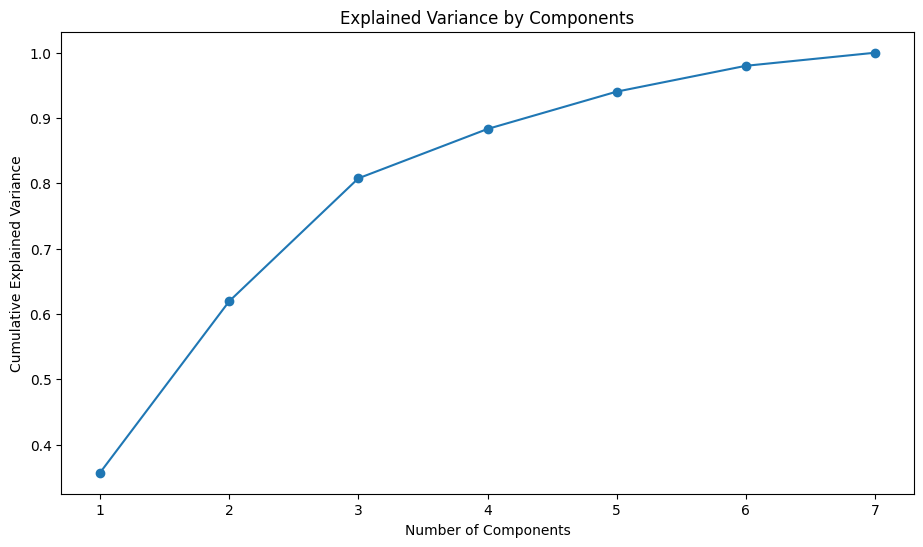

In [12]:
plt.figure(figsize = (11,6))
plt.plot(range(1,8), pca.explained_variance_ratio_.cumsum(), marker = 'o')
plt.title('Explained Variance by Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

In [13]:
pca = PCA(n_components = 3)
pca.fit(segmentation_std)

PCA(n_components=3)

In [14]:
components_df = pd.DataFrame(data = pca.components_,
                           columns = df_segmentation.columns.values,
                           index = ['Component 1', 'Component 2', 'Component 3'])
components_df

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
Component 1,-0.314695,-0.191704,0.326100,0.156841,0.524525,0.492059,0.464789
Component 2,0.458006,0.512635,0.312208,0.639807,0.124683,0.014658,-0.069632
Component 3,-0.293013,-0.441977,0.609544,0.275605,-0.165662,-0.395505,-0.295685


In [15]:
scores_pca = pca.transform(segmentation_std)
scores_pca

array([[ 2.51474593,  0.83412239,  2.1748059 ],
       [ 0.34493528,  0.59814564, -2.21160279],
       [-0.65106267, -0.68009318,  2.2804186 ],
       ...,
       [-1.45229829, -2.23593665,  0.89657125],
       [-2.24145254,  0.62710847, -0.53045631],
       [-1.86688505, -2.45467234,  0.66262172]])

In [16]:
wcss = []
for i in range(1,11):
    kmeans_pca = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans_pca.fit(scores_pca)
    wcss.append(kmeans_pca.inertia_) 

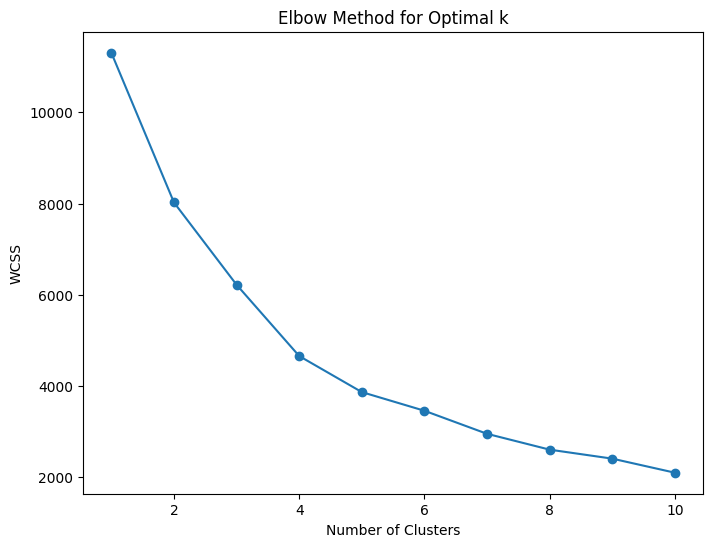

In [17]:
plt.figure(figsize = (8,6))
plt.plot(range(1, 11), wcss, marker = 'o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.show()

In [18]:
kmeans_pca = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42)
kmeans_pca.fit(scores_pca)

KMeans(n_clusters=4, random_state=42)

In [19]:
pca_df = pd.DataFrame(data=scores_pca , columns = ['PCA1', 'PCA2', 'PCA3'])

In [20]:
cluster_labels = kmeans_pca.labels_
pca_df['Cluster'] = cluster_labels
pca_df.head()

,PCA1,PCA2,PCA3,Cluster
0,2.514746,0.834122,2.174806,3
1,0.344935,0.598146,-2.211603,2
2,-0.651063,-0.680093,2.280419,1
3,1.714316,-0.579927,0.730731,0
4,1.626745,-0.440496,1.244909,0


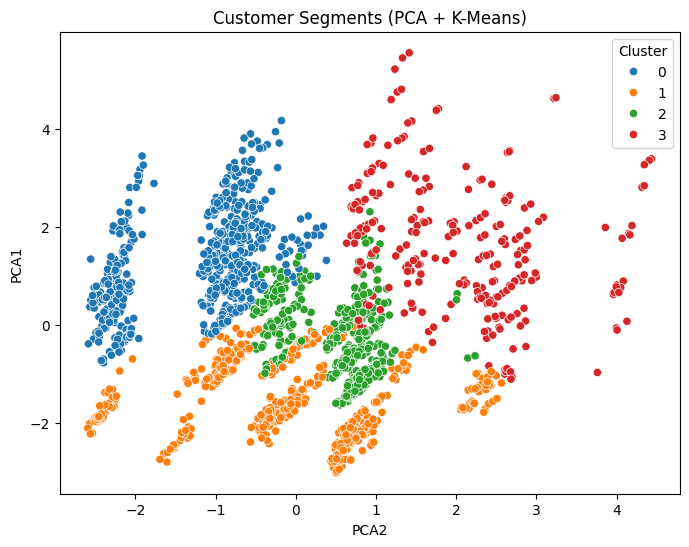

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=pca_df['PCA2'], 
    y=pca_df['PCA1'], 
    hue=pca_df['Cluster'],
    palette='tab10',
)
plt.title('Customer Segments (PCA + K-Means)')
plt.show()

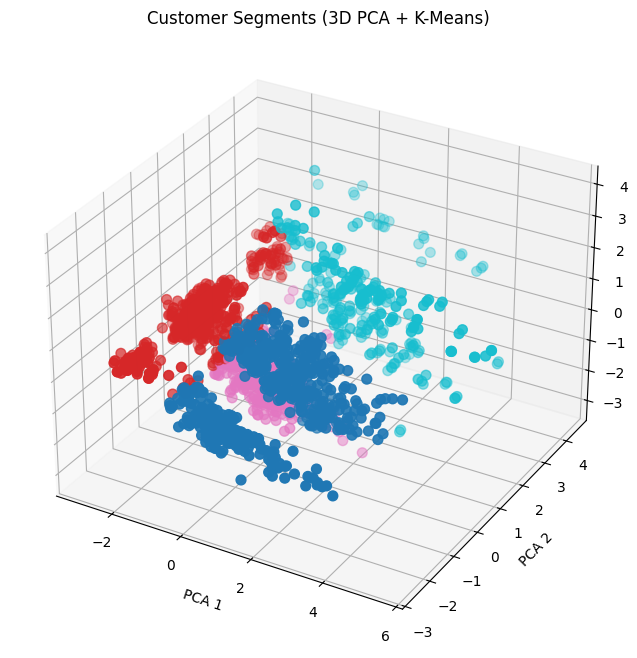

In [22]:
from mpl_toolkits.mplot3d import Axes3D 
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_df['PCA1'],
    pca_df['PCA2'],
    pca_df['PCA3'],
    c=pca_df['Cluster'],
    cmap='tab10',
    s=50
)

ax.set_title('Customer Segments (3D PCA + K-Means)')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')

plt.show()

In [23]:
import plotly.express as px
fig = px.scatter_3d(
    pca_df,
    x='PCA1', y='PCA2', z='PCA3',
    color='Cluster',
    title='3D PCA Customer Segments',
)
fig.show()

In [24]:
df_segmentation = df_segmentation.reset_index(drop=False)
pca_df = pca_df.reset_index(drop=True)

df_clustered = pd.concat([df_segmentation, pca_df['Cluster']], axis=1)

In [25]:
df_clustered

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,Cluster
0,100000001,0,0,67,2,124670,1,2,3
1,100000002,1,1,22,1,150773,1,2,2
2,100000003,0,0,49,1,89210,0,0,1
3,100000004,0,0,45,1,171565,1,1,0
4,100000005,0,0,53,1,149031,1,1,0
...,...,...,...,...,...,...,...,...,...
1995,100001996,1,0,47,1,123525,0,0,1
1996,100001997,1,1,27,1,117744,1,0,2
1997,100001998,0,0,31,0,86400,0,0,1
1998,100001999,1,1,24,1,97968,0,0,1


In [26]:
df_summary = df_clustered.groupby('Cluster').mean().round(2)
df_summary

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
Cluster,,,,,,,,
0,1.000007e+08,0.00,0.04,36.67,0.68,138482.19,1.20,1.26
1,1.000013e+08,0.63,0.45,33.47,0.94,88824.15,0.08,0.01
2,1.000010e+08,0.76,0.97,27.89,1.01,119503.42,1.06,0.81
3,1.000009e+08,0.49,0.68,55.92,2.13,158400.88,1.13,1.10


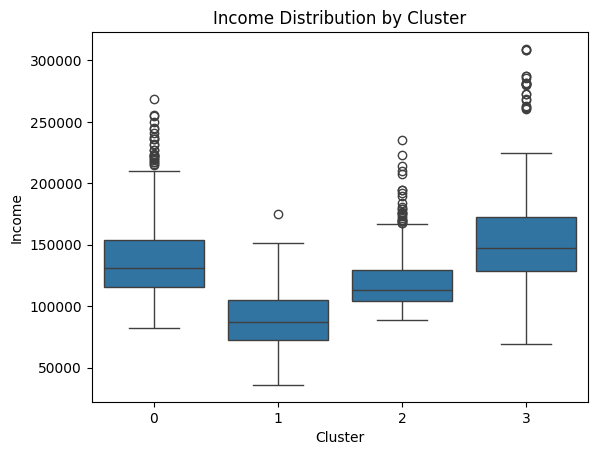

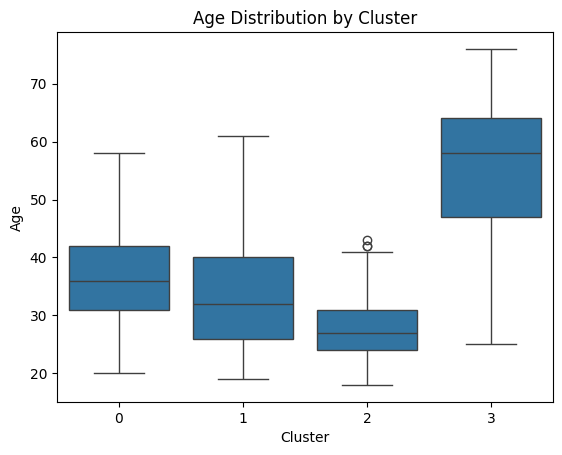

In [27]:
sns.boxplot(x='Cluster', y='Income', data=df_clustered)
plt.title('Income Distribution by Cluster')
plt.show()

sns.boxplot(x='Cluster', y='Age', data=df_clustered)
plt.title('Age Distribution by Cluster')
plt.show()


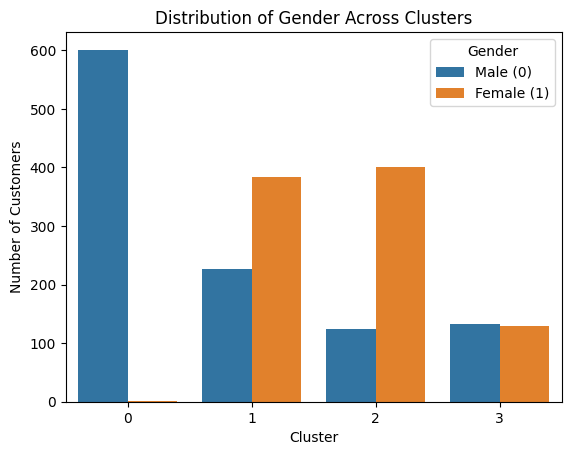

In [28]:
sns.countplot(x='Cluster', hue='Sex', data=df_clustered)

plt.title('Distribution of Gender Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.legend(title='Gender', labels=['Male (0)', 'Female (1)'])
plt.show()

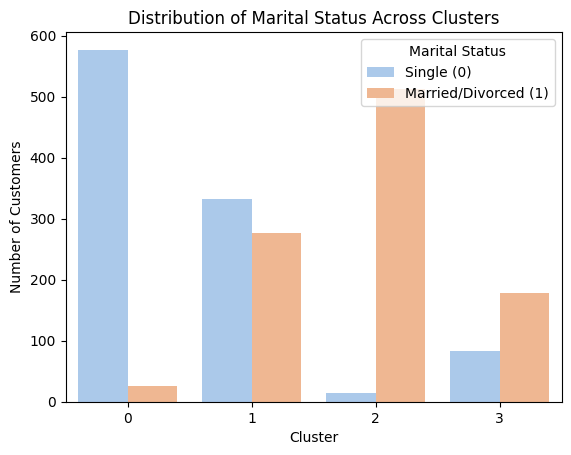

In [29]:
sns.countplot(x='Cluster', hue='Marital status', data=df_clustered, palette='pastel')

plt.title('Distribution of Marital Status Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.legend(title='Marital Status', labels=['Single (0)', 'Married/Divorced (1)'])
plt.show()

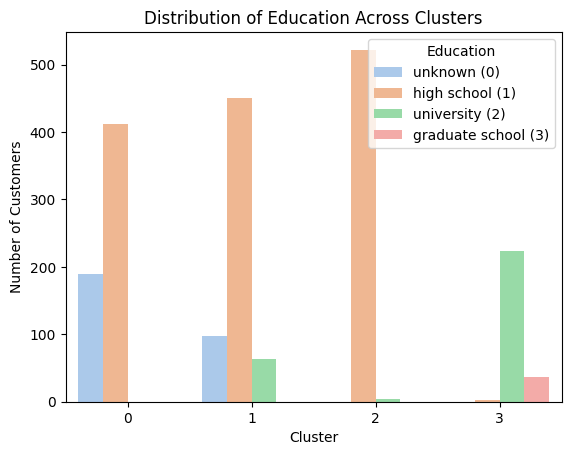

In [30]:
sns.countplot(x='Cluster', hue='Education', data=df_clustered, palette='pastel')

plt.title('Distribution of Education Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.legend(title='Education', labels=['unknown (0)', 'high school (1)', 'university (2)', 'graduate school (3)'])
plt.show()

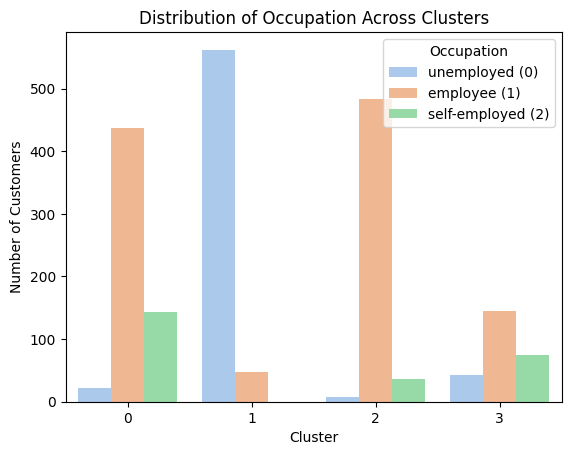

In [31]:
sns.countplot(x='Cluster', hue='Occupation', data=df_clustered, palette='pastel')

plt.title('Distribution of Occupation Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.legend(title='Occupation', labels=['unemployed (0)', 'employee (1)', 'self-employed (2)'])
plt.show()

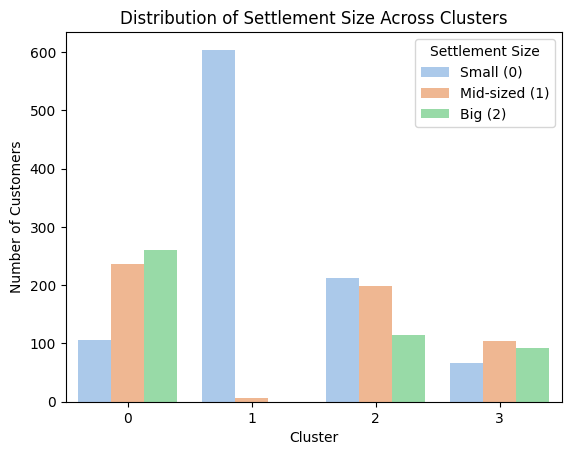

In [32]:
sns.countplot(x='Cluster', hue='Settlement size', data=df_clustered, palette='pastel')

plt.title('Distribution of Settlement Size Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.legend(title='Settlement Size', labels=['Small (0)', 'Mid-sized (1)', 'Big (2)'])
plt.show()

In [33]:
cluster_labels = {
    0: 'career-oriented',
    1: 'economically vulnerable',
    2: 'working families',
    3: 'high-income seniors' 
}

df_clustered['Cluster_Label'] = df_clustered['Cluster'].map(cluster_labels)

In [34]:
df_clustered.head()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,Cluster,Cluster_Label
0,100000001,0,0,67,2,124670,1,2,3,high-income seniors
1,100000002,1,1,22,1,150773,1,2,2,working families
2,100000003,0,0,49,1,89210,0,0,1,economically vulnerable
3,100000004,0,0,45,1,171565,1,1,0,career-oriented
4,100000005,0,0,53,1,149031,1,1,0,career-oriented


In [35]:
df_predict = purchase_df[['Sex', 'Marital status', 'Age', 'Education', 'Income', 'Occupation', 'Settlement size']]

In [36]:
df_std = scaler.transform(df_predict)

In [37]:
df_pca = pca.transform(df_std)

In [38]:
purchase_df['Predicted_Cluster'] = kmeans_pca.predict(df_pca)

In [39]:
cluster_labels = {
    0: 'career-oriented',
    1: 'economically vulnerable',
    2: 'working families',
    3: 'high-income seniors' 
}

purchase_df['Cluster_Label'] = purchase_df['Predicted_Cluster'].map(cluster_labels)

In [40]:
purchase_df.head()

,ID,Day,Incidence,Brand,Quantity,Last_Inc_Brand,Last_Inc_Quantity,Price_1,Price_2,Price_3,...,Promotion_5,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,Predicted_Cluster,Cluster_Label
0,200000001,1,0,0,0,0,0,1.59,1.87,2.01,...,0,0,0,47,1,110866,1,0,0,career-oriented
1,200000001,11,0,0,0,0,0,1.51,1.89,1.99,...,0,0,0,47,1,110866,1,0,0,career-oriented
2,200000001,12,0,0,0,0,0,1.51,1.89,1.99,...,0,0,0,47,1,110866,1,0,0,career-oriented
3,200000001,16,0,0,0,0,0,1.52,1.89,1.98,...,0,0,0,47,1,110866,1,0,0,career-oriented
4,200000001,18,0,0,0,0,0,1.52,1.89,1.99,...,0,0,0,47,1,110866,1,0,0,career-oriented


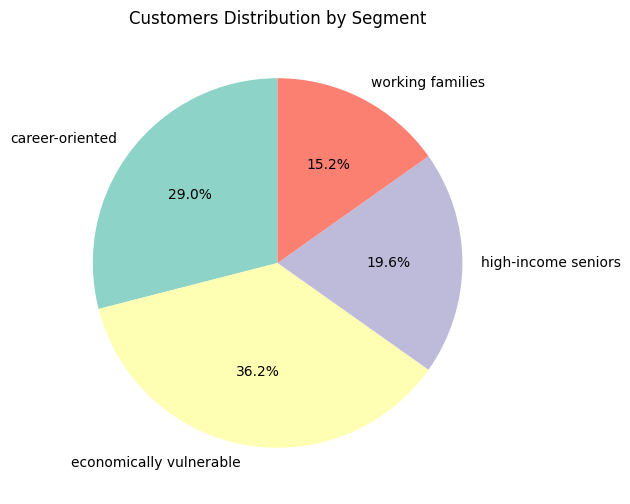

In [41]:
cluster_counts = purchase_df.groupby('Cluster_Label')['ID'].nunique()
plt.figure(figsize=(6,6))
plt.pie(cluster_counts,
        labels=cluster_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=plt.cm.Set3.colors)

plt.title('Customers Distribution by Segment')
plt.show()

In [42]:
purchase_by_segment = purchase_df.groupby('Cluster_Label')['Incidence'].sum()
print(purchase_by_segment)

Cluster_Label
career-oriented            5070
economically vulnerable    4131
high-income seniors        3372
working families           2065
Name: Incidence, dtype: int64


In [43]:
purchases_only = purchase_df[purchase_df['Incidence'] == 1]

incidence_counts = purchases_only['Cluster_Label'].value_counts()

incidence_share = incidence_counts / incidence_counts.sum()

print(incidence_share)

Cluster_Label
career-oriented            0.346359
economically vulnerable    0.282211
high-income seniors        0.230359
working families           0.141071
Name: count, dtype: float64


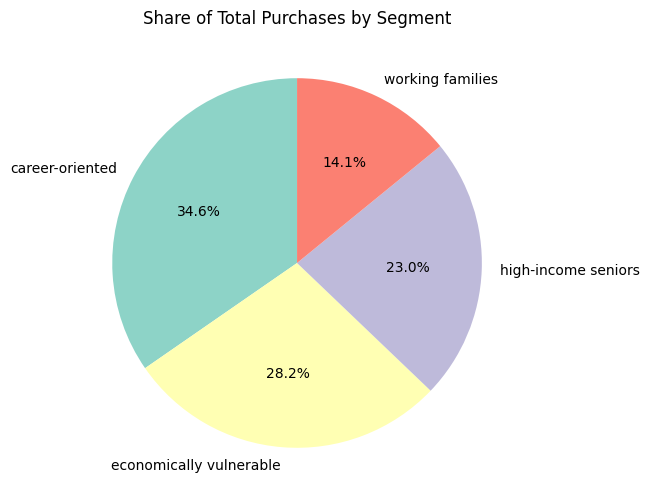

In [44]:
plt.figure(figsize=(6,6))
plt.pie(incidence_share, labels=incidence_share.index,
        autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3.colors)
plt.title('Share of Total Purchases by Segment')
plt.show()

In [45]:
visits_per_segment = purchase_df.groupby('Cluster_Label')['Incidence'].count()
print(visits_per_segment.sort_values(ascending=False))

Cluster_Label
economically vulnerable    20689
career-oriented            17471
high-income seniors        11502
working families            9031
Name: Incidence, dtype: int64


In [46]:
brand_pref = purchase_df[purchase_df['Brand'] != 0] \
  .groupby(['Cluster_Label', 'Brand']) \
    .size().reset_index(name='Count')

In [47]:
favorite_brand = brand_pref.loc[brand_pref.groupby('Cluster_Label')['Count'].idxmax()]
print(favorite_brand)

              Cluster_Label  Brand  Count
4           career-oriented      5   3189
6   economically vulnerable      2   2389
13      high-income seniors      4   2129
16         working families      2    669


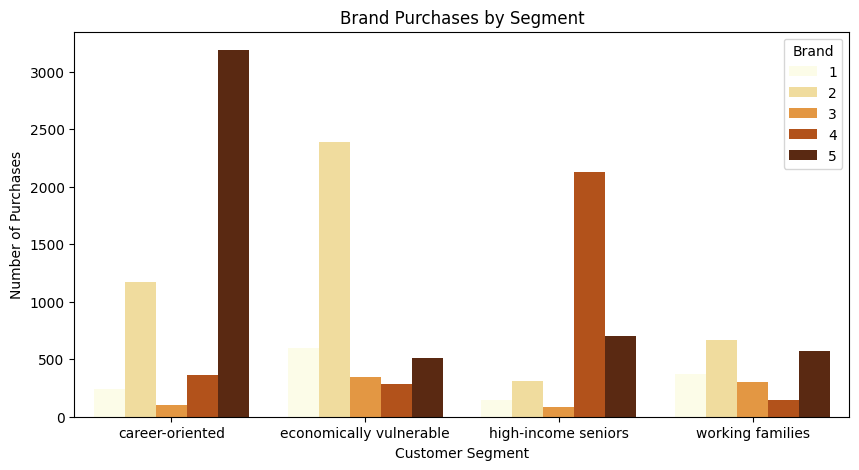

In [48]:
plt.figure(figsize=(10,5))
sns.barplot(data=brand_pref, x='Cluster_Label', y='Count', hue='Brand', palette='YlOrBr')
plt.title('Brand Purchases by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Purchases')
plt.legend(title='Brand')
plt.show()

In [49]:
for i in range(1, 6):
    purchase_df.loc[purchase_df['Brand'] == i, 'Revenue'] = purchase_df['Quantity'] * purchase_df[f'Price_{i}']

In [52]:
purchase_df['Revenue'] = purchase_df['Revenue'].fillna(0)

In [55]:
brand_revenue = purchase_df.groupby('Brand')['Revenue'].sum().reset_index()
brand_revenue = brand_revenue[brand_revenue['Brand'] != 0]
print(brand_revenue)

   Brand   Revenue
1      1   6305.65
2      2  21768.31
3      3   6021.52
4      4  19040.10
5      5  29621.00


In [57]:
segment_brand = purchase_df.groupby(['Cluster_Label', 'Brand'])['Revenue'].sum().reset_index()
segment_brand = segment_brand[segment_brand['Brand'] != 0]

In [60]:
revenue_table = purchase_df.pivot_table(
    index='Cluster_Label',
    columns='Brand',
    values='Revenue',
    aggfunc='sum',
    fill_value=0
)
print(revenue_table)

Brand                      0        1         2        3         4         5
Cluster_Label                                                               
career-oriented          0.0   912.12   5222.99   603.79   2268.95  17838.72
economically vulnerable  0.0  2807.51  11742.86  2388.88   1910.89   2638.52
high-income seniors      0.0   716.25   1419.99   725.54  13695.10   5505.01
working families         0.0  1869.77   3382.47  2303.31   1165.16   3638.75


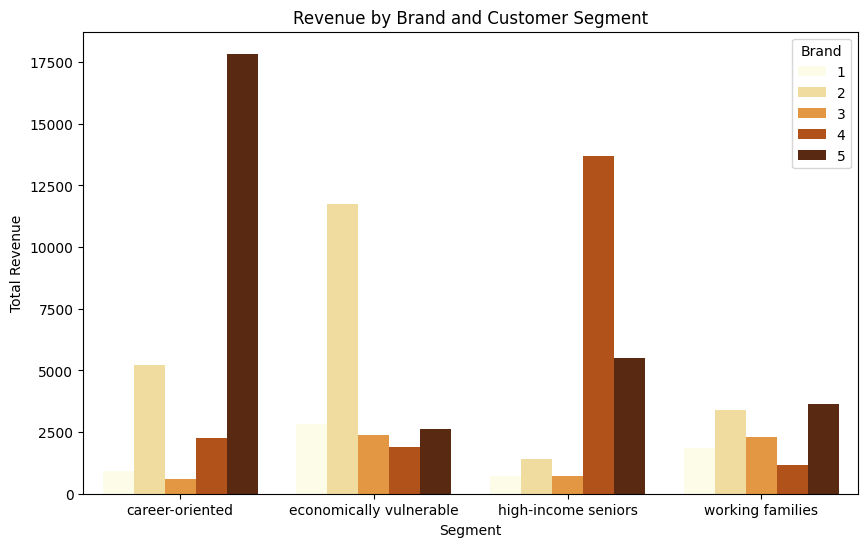

In [66]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=segment_brand,
    x='Cluster_Label',
    y='Revenue',
    hue='Brand',
    palette='YlOrBr'
)
plt.title('Revenue by Brand and Customer Segment')
plt.ylabel('Total Revenue')
plt.xlabel('Segment')
plt.legend(title='Brand')
plt.show()

In [67]:
purchase_df.to_csv('merged_dataset.csv', index=False)